80 image, 4 esp, 11 k, 1 segment

In [23]:
import pandas as pd
CSV_PATH = f"../results/100_imgs/combined_results.csv"
df = pd.read_csv(CSV_PATH)

In [24]:
import numpy as np

import pandas as pd
df = pd.read_csv(CSV_PATH)
# numeric safety
df["eps"] = pd.to_numeric(df["eps"], errors="coerce")
df["k"]   = pd.to_numeric(df["k"], errors="coerce")
df["lb_minus_rhs"] = pd.to_numeric(df["lb_minus_rhs"], errors="coerce")

# make sure domains_visited exists
assert "domains_visited" in df.columns

# BnB flag
df["bnb_entered"] = df["domains_visited"] > 0

# result mapping
RESULT_RENAME = {
    "sat True": "Unsafe (counterexample)",
    "unsat False": "Safe (proved)",
    "timeout False": "Timeout / Unknown",
    "error": "Error",
    "sat False": "Unsafe (counterexample with BnB)",
}

df["result_label"] = df["result"].map(RESULT_RENAME).fillna(df["result"])

df["glb_status"] = np.where(
    np.isfinite(df["lb_minus_rhs"]),
    "Finite lower bound",
    "Lower bound = -inf"
)

summary = (
    df
    .groupby(["result_label", "bnb_entered", "glb_status"])
    .size()
    .reset_index(name="Count")
)

summary

,result_label,bnb_entered,glb_status,Count
0,Error,False,Lower bound = -inf,1124
1,Safe (proved),False,Finite lower bound,3998
2,Timeout / Unknown,True,Finite lower bound,2341
3,Unsafe (counterexample),False,Lower bound = -inf,1196


In [16]:
import pandas as pd
import re
from IPython.display import display, Markdown

# -----------------------
# normalize
# -----------------------
df["eps"] = pd.to_numeric(df["eps"], errors="coerce")
df["k"]   = pd.to_numeric(df["k"], errors="coerce")
df["result"] = df["result"].astype(str)
df["tag_norm"] = df["tag"].astype(str).str.lower().str.strip()

# -----------------------
# extract seg id from tag
# -----------------------
def extract_seg(tag: str):
    if "global" in tag:
        return "global"
    m = re.search(r"seg(\d+)", tag)
    if m:
        return int(m.group(1))
    return "unseg"

df["seg_id"] = df["tag_norm"].apply(extract_seg)

# -----------------------
# classify Global / Mask / Non-mask from tag
# -----------------------
def extract_variant(tag: str):
    t = str(tag).lower()

    # global first (dominates)
    if "global" in t:
        return "Global"

    # non-mask patterns (put before "mask" to avoid substring confusion)
    if ("nonmask" in t) or ("non-mask" in t) or ("fixnonmask" in t) or ("fix_nonmask" in t) or ("non_mask" in t):
        return "Non-mask"

    # mask patterns
    if ("fixmask" in t) or ("fix_mask" in t) or ("mask" in t):
        return "Mask"

    return "Unknown"

df["variant"] = df["tag_norm"].apply(extract_variant)

# -----------------------
# group by eps, seg, variant, k, result
# -----------------------
summary = (
    df
    .dropna(subset=["eps", "k"])
    .groupby(["eps", "seg_id", "variant", "k", "result"])
    .size()
    .reset_index(name="Count")
)

# pretty result names
RESULT_RENAME = {
    "sat True": "Unsafe (counterexample)",
    "unsat False": "Safe (proved)",
    "timeout False": "Timeout / Unknown",
    "error": "Error",
    "sat False": "Unsafe (counterexample with BnB)",
}

# -----------------------
# build tables per (eps, seg, variant)
# -----------------------
tables = {}

for (eps, seg, variant), dfe in summary.groupby(["eps", "seg_id", "variant"]):
    table = (
        dfe
        .pivot_table(
            index="k",
            columns="result",
            values="Count",
            fill_value=0
        )
        .reset_index()
        .sort_values("k")
        .rename(columns=RESULT_RENAME)
    )

    tables[(eps, seg, variant)] = table

# -----------------------
# display nicely
# -----------------------
for (eps, seg, variant), table in sorted(tables.items(), key=lambda x: (x[0][0], str(x[0][1]), x[0][2])):
    display(Markdown(f"### ε = {eps} | seg = {seg} | variant = {variant}"))
    display(table)

### ε = 0.0001 | seg = 0 | variant = Mask

result,k,Unsafe (counterexample),Timeout / Unknown,Safe (proved)
0,2,0.0,42.0,38.0
1,10,0.0,42.0,38.0
2,20,0.0,42.0,38.0
3,24,0.0,42.0,38.0
4,30,0.0,43.0,37.0
5,50,0.0,42.0,38.0
6,196,0.0,42.0,38.0
7,784,0.0,42.0,38.0
8,12544,15.0,27.0,38.0
9,25088,27.0,15.0,38.0


### ε = 0.0001 | seg = 0 | variant = Non-mask

result,k,Unsafe (counterexample),Timeout / Unknown,Safe (proved)
0,2,0.0,42.0,38.0
1,10,0.0,42.0,38.0
2,20,0.0,42.0,38.0
3,24,0.0,42.0,38.0
4,30,0.0,42.0,38.0
5,50,0.0,42.0,38.0
6,196,0.0,42.0,38.0
7,784,0.0,42.0,38.0
8,12544,41.0,1.0,38.0
9,25088,42.0,5.0,33.0


### ε = 0.0001 | seg = global | variant = Global

...

result,k,Unsafe (counterexample),Timeout / Unknown,Safe (proved)
0,2,0.0,42.0,38.0
1,10,0.0,42.0,38.0
2,20,0.0,42.0,38.0
3,24,0.0,42.0,38.0
4,30,0.0,42.0,38.0
5,50,0.0,42.0,38.0
6,196,0.0,42.0,38.0
7,784,0.0,42.0,38.0
8,12544,15.0,28.0,37.0
9,25088,27.0,23.0,30.0


### ε = 0.0004 | seg = 0 | variant = Non-mask

result,k,Unsafe (counterexample),Timeout / Unknown,Safe (proved)
0,2,0.0,42.0,38.0
1,10,0.0,42.0,38.0
2,20,0.0,42.0,38.0
3,24,0.0,42.0,38.0
4,30,0.0,42.0,38.0
5,50,0.0,42.0,38.0
6,196,0.0,42.0,38.0
7,784,0.0,42.0,38.0
8,12544,41.0,28.0,11.0
9,25088,44.0,33.0,3.0


### ε = 0.0004 | seg = global | variant = Global

result,k,Unsafe (counterexample),Timeout / Unknown,Safe (proved)
0,2,0.0,42.0,38.0
1,10,0.0,42.0,38.0
2,20,0.0,42.0,38.0
3,24,0.0,42.0,38.0
4,30,0.0,42.0,38.0
5,50,0.0,42.0,38.0
6,196,0.0,42.0,38.0
7,784,0.0,42.0,38.0
8,12544,43.0,33.0,4.0
9,25088,44.0,36.0,0.0


In [25]:
import pandas as pd

# --------------------------------
# CONFIG (change if needed)
# --------------------------------
N_EPS = 4
N_K = 11
N_VARIANTS = 3   # global, fix_mask, fix_nonmask
N_SEGS = 1

EXPECTED_ROWS_PER_IMAGE = N_EPS * N_K * N_VARIANTS * N_SEGS
print("Expected rows per image:", EXPECTED_ROWS_PER_IMAGE)

# --------------------------------
# COUNT how many times each image appears
# --------------------------------
counts = (
    df["image"]
    .value_counts()
    .rename("n_rows")
    .reset_index()
    .rename(columns={"index": "image"})
)

# --------------------------------
# CHECK completeness
# --------------------------------
counts["is_complete"] = counts["n_rows"] == EXPECTED_ROWS_PER_IMAGE

# --------------------------------
# FINAL ANSWER
# --------------------------------
n_total = counts.shape[0]
n_complete = counts["is_complete"].sum()
n_incomplete = n_total - n_complete

print("Total images:", n_total)
print("Complete images:", n_complete)
print("Incomplete images:", n_incomplete)

# --------------------------------
# OPTIONAL: see bad ones
# --------------------------------
print("\nIncomplete images:")
print(
    counts[~counts["is_complete"]]
    .sort_values("n_rows")
    .head(20)
    .to_string(index=False)
)

Expected rows per image: 132
Total images: 34
Complete images: 3
Incomplete images: 31

Incomplete images:
                image  n_rows  is_complete
n01704323_triceratops      99        False
      n01806567_quail     108        False
   n01770393_scorpion     112        False
 n01770081_harvestman     114        False
      n01855672_goose     114        False
     n01843383_toucan     115        False
      n01818515_macaw     117        False
  n01784675_centipede     117        False
       n01776313_tick     117        False
  n01774750_tarantula     117        False
n01833805_hummingbird     117        False
n01755581_diamondback     117        False
 n01756291_sidewinder     118        False
   n01667778_terrapin     118        False
    n01806143_peacock     118        False
  n01768244_trilobite     118        False
  n01807496_partridge     119        False
      n01687978_agama     119        False
     n01824575_coucal     119        False
   n01820546_lorikeet     120    

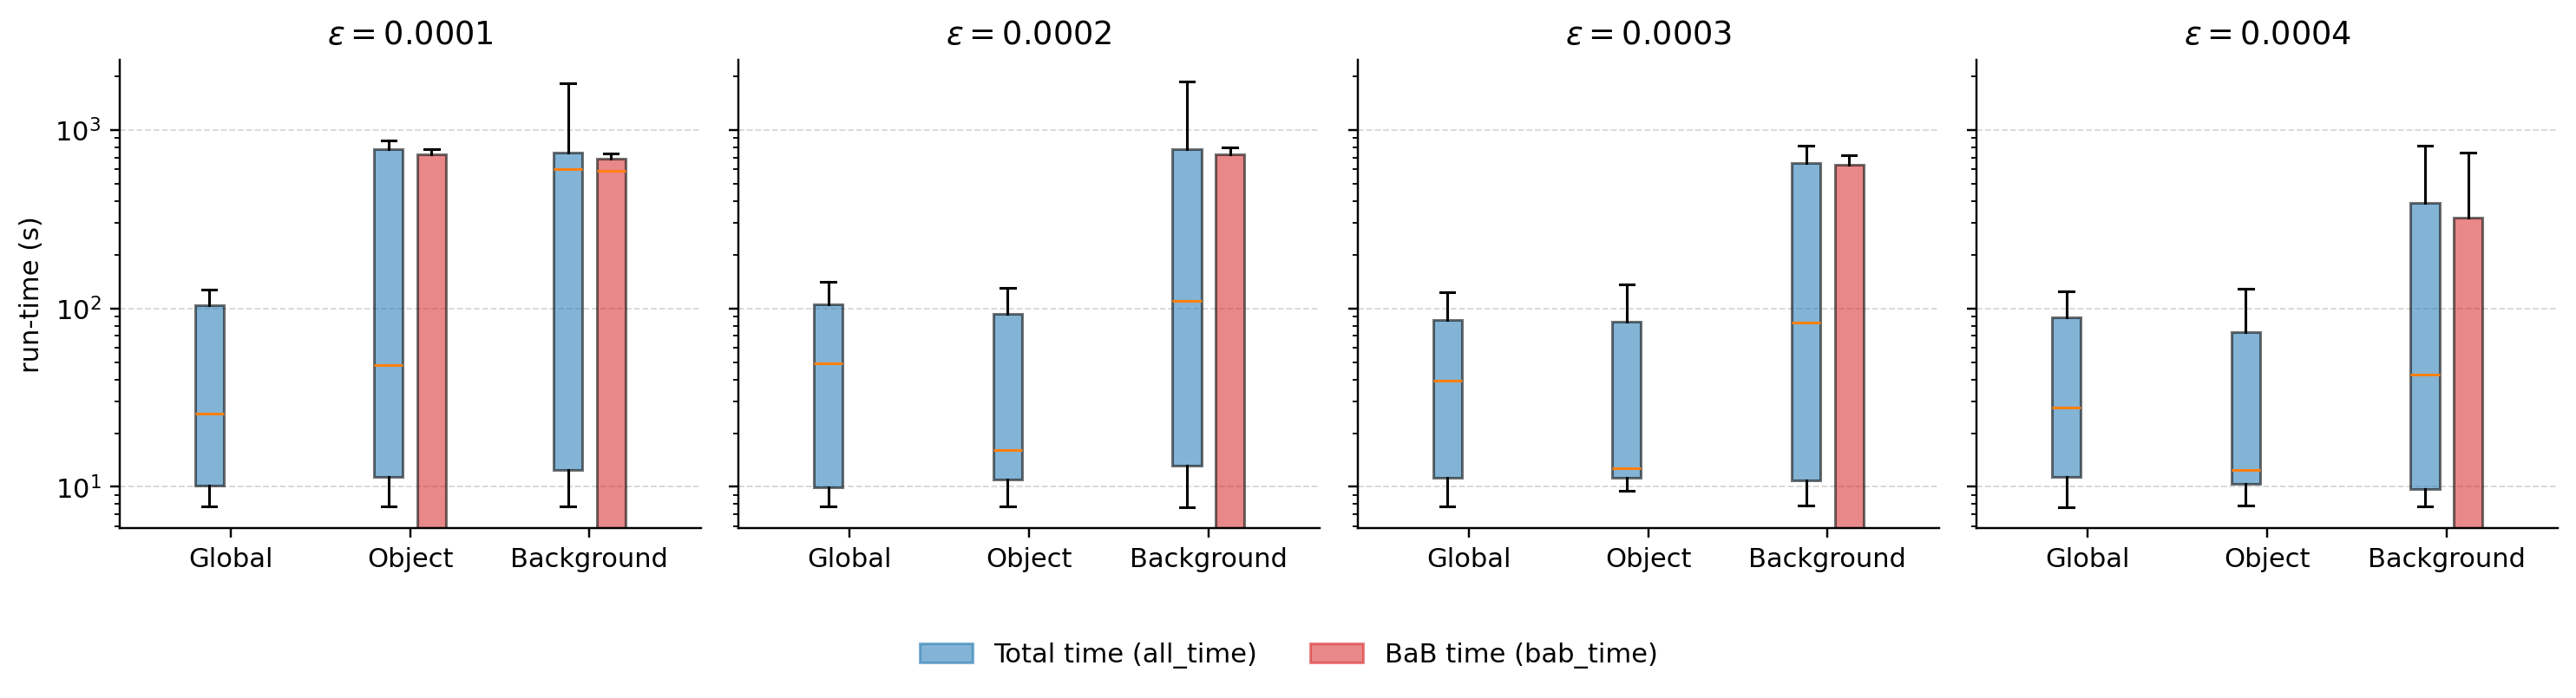

In [26]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------
# Helpers
# ---------------------------
ALL_COL = "all_time"
BAB_COL = "bab_time"

def filter_by_tag_contains(frame: pd.DataFrame, include_any=(), include_all=(), exclude_any=()):
    tag = frame["tag"].astype(str)
    keep = pd.Series(True, index=frame.index)

    if include_any:
        keep_any = pd.Series(False, index=frame.index)
        for s in include_any:
            keep_any |= tag.str.contains(s, case=False, na=False)
        keep &= keep_any

    for s in include_all:
        keep &= tag.str.contains(s, case=False, na=False)

    if exclude_any:
        for s in exclude_any:
            keep &= ~tag.str.contains(s, case=False, na=False)

    return frame[keep].copy()

def sanitize_numeric(frame: pd.DataFrame):
    out = frame.copy()
    out["eps"] = pd.to_numeric(out["eps"], errors="coerce")
    out["k"] = pd.to_numeric(out["k"], errors="coerce")
    out[ALL_COL] = pd.to_numeric(out[ALL_COL], errors="coerce")
    if BAB_COL in out.columns:
        out[BAB_COL] = pd.to_numeric(out[BAB_COL], errors="coerce")

    out = out.dropna(subset=["eps", "k", ALL_COL]).copy()
    out = out[out[ALL_COL] > 0].copy()

    if BAB_COL in out.columns:
        out[BAB_COL] = out[BAB_COL].fillna(0)
        out.loc[out[BAB_COL] < 0, BAB_COL] = 0

    return out

def paired_boxplot_one_panel(ax, data_pairs, base_labels):
    centers = np.arange(1, len(base_labels) + 1)

    pos_total = centers - 0.12
    pos_bab   = centers + 0.12

    total_data = [p[0] for p in data_pairs]
    bab_data   = [p[1] for p in data_pairs]

    bp1 = ax.boxplot(
        total_data, positions=pos_total, widths=0.16,
        showfliers=False, patch_artist=True
    )
    bp2 = ax.boxplot(
        bab_data, positions=pos_bab, widths=0.16,
        showfliers=False, patch_artist=True
    )

    for b in bp1["boxes"]:
        b.set_facecolor("#1f77b4")
        b.set_alpha(0.55)
    for b in bp2["boxes"]:
        b.set_facecolor("#d62728")
        b.set_alpha(0.55)

    for key in ["whiskers", "caps", "medians"]:
        for line in bp1[key]:
            line.set_linewidth(1.0)
        for line in bp2[key]:
            line.set_linewidth(1.0)

    ax.set_xticks(centers)
    ax.set_xticklabels(base_labels)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

# ---------------------------
# Build subsets
# ---------------------------
if "is_global" in df.columns:
    df_global = df[df["is_global"] == True].copy()
else:
    df_global = filter_by_tag_contains(df, include_any=("global",))

df_object = filter_by_tag_contains(df, include_any=("fixnonmask", "fix_nonmask", "fix_non_mask"))
df_background = filter_by_tag_contains(df, include_any=("fixmask", "fix_mask"))

df_global = sanitize_numeric(df_global)
df_object = sanitize_numeric(df_object)
df_background = sanitize_numeric(df_background)

# ---------------------------
# FIXED k silently
# ---------------------------
FIXED_K = 50176

df_global = df_global[df_global["k"] == FIXED_K]
df_object = df_object[df_object["k"] == FIXED_K]
df_background = df_background[df_background["k"] == FIXED_K]

# ---------------------------
# TWO EPS SIDE BY SIDE
# ---------------------------

eps_vals = sorted(eps_vals)

cols = len(eps_vals)
rows = 1

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 3.4, 3.2),
    dpi=220,
    sharey=True,
)

axes = np.array(axes).reshape(1, cols)

base_labels = ["Global", "Object", "Background"]

for j, eps in enumerate(eps_vals):

    ax = axes[0, j]

    g_all = df_global[df_global["eps"] == eps][ALL_COL].values
    g_bab = df_global[df_global["eps"] == eps][BAB_COL].values

    o_all = df_object[df_object["eps"] == eps][ALL_COL].values
    o_bab = df_object[df_object["eps"] == eps][BAB_COL].values

    b_all = df_background[df_background["eps"] == eps][ALL_COL].values
    b_bab = df_background[df_background["eps"] == eps][BAB_COL].values

    paired_boxplot_one_panel(
        ax,
        data_pairs=[(g_all, g_bab), (o_all, o_bab), (b_all, b_bab)],
        base_labels=base_labels
    )

    ax.set_title(rf"$\epsilon={eps:g}$")

    ax.set_yscale("log")

    if j == 0:
        ax.set_ylabel("run-time (s)")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ---------------------------
# Title + legend
# ---------------------------

# fig.suptitle(
#    "Verification run-time per ε: total time with embedded BaB time",
#    y=1.05
# )

total_patch = mpatches.Patch(color="#1f77b4", alpha=0.55, label="Total time (all_time)")
bab_patch   = mpatches.Patch(color="#d62728", alpha=0.55, label="BaB time (bab_time)")

fig.legend(
    handles=[total_patch, bab_patch],
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.15),
)

plt.tight_layout()
plt.show()

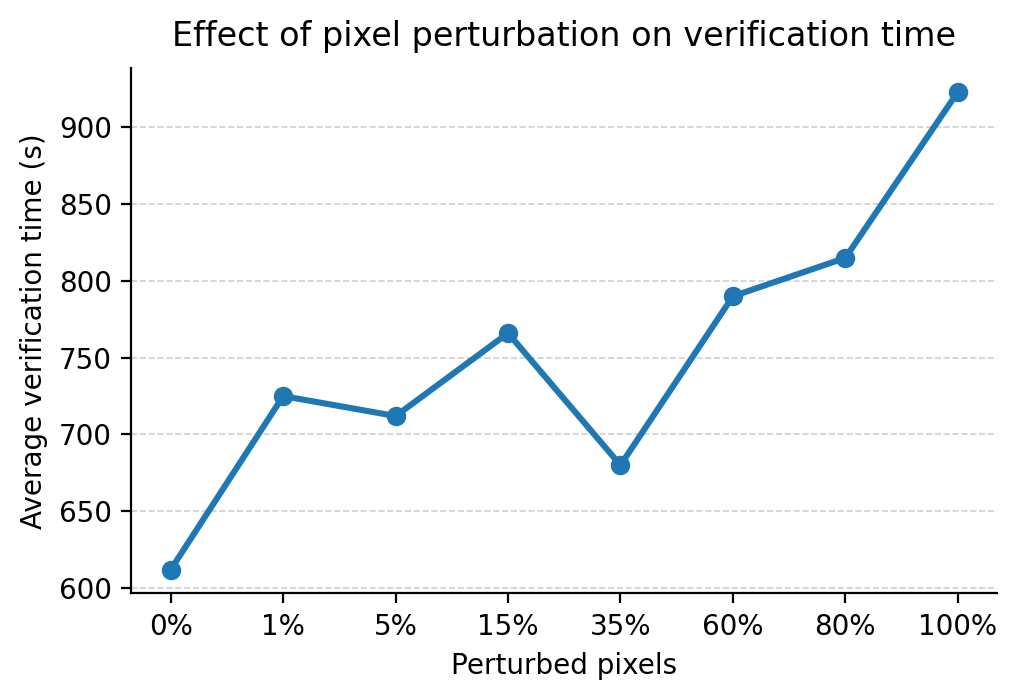

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# ---- your aggregated data (example) ----
pixel_vals = np.array([0, 1, 5, 15, 35, 60, 80, 100])
avg_time = np.array([612, 725, 712, 766, 680, 790, 815, 923])

# ---- categorical x positions (equal spacing) ----
x_pos = np.arange(len(pixel_vals))

# ---- plot ----
plt.figure(figsize=(5.2, 3.6), dpi=200)

plt.plot(
    x_pos,
    avg_time,
    marker="o",
    linewidth=2.2,
    markersize=6,
)

# ---- axis styling ----
plt.xticks(x_pos, [f"{p}%" for p in pixel_vals])
plt.xlabel("Perturbed pixels")
plt.ylabel("Average verification time (s)")

plt.title("Effect of pixel perturbation on verification time", pad=8)

# subtle grid (y only)
plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# remove top/right spines (paper style)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

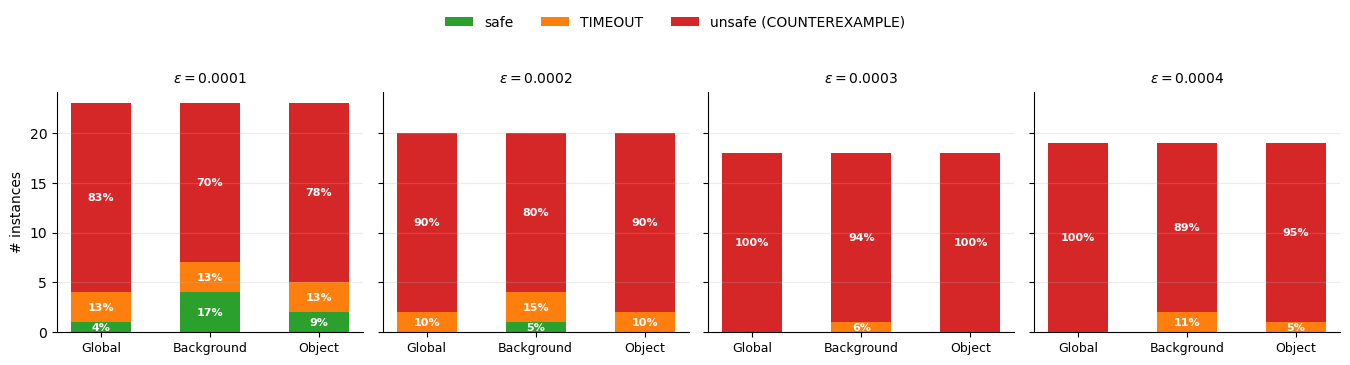

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
PAIR_COLS = ["image", "eps", "k"]

VARIANTS = ["Global", "Background", "Object"]
XTICK_LABELS = ["Global", "Background", "Object"]

RESULT_RENAME = {
    "unsat False": "safe",
    "timeout False": "TIMEOUT",
    "sat True": "unsafe (COUNTEREXAMPLE)",
}

RESULT_COLORS = {
    "unsafe (COUNTEREXAMPLE)": "#d62728",
    "safe": "#2ca02c",
    "TIMEOUT": "#ff7f0e",
}

RESULT_ORDER = ["safe", "TIMEOUT", "unsafe (COUNTEREXAMPLE)"]

FIXED_K = 50176   # silently restrict to this

# -----------------------------
# LOAD / CLEAN
# -----------------------------
df = df.copy()
df["eps"] = pd.to_numeric(df["eps"], errors="coerce")
df["k"]   = pd.to_numeric(df["k"], errors="coerce")
df["result"] = df["result"].astype(str)

# -----------------------------
# VARIANT CLASSIFIER
# -----------------------------
def classify_variant(row):
    pat = str(row.get("pattern", "")).lower()
    tag = str(row.get("tag", "")).lower()
    vnn = str(row.get("vnnlib", "")).lower()
    is_global = bool(row.get("is_global", False))

    if is_global or pat == "global" or "_global" in tag or "_global" in vnn:
        return "Global"

    s = " ".join([pat, tag, vnn])

    if any(k in s for k in ["fix_mask", "fix-mask", "fixmask"]):
        return "Background"
    if any(k in s for k in ["fix_nonmask", "fix-nonmask", "fixnonmask", "fix_non_mask"]):
        return "Object"

    if any(k in s for k in ["background", "bg", "nonmask", "non-mask"]):
        return "Background"
    if any(k in s for k in [" object", " obj", "foreground"]):
        return "Object"

    return None

df["variant"] = df.apply(classify_variant, axis=1)
df = df[df["variant"].isin(VARIANTS)].copy()

# Keep only seg0 for non-global
if "segment_index" in df.columns:
    df = df[(df["variant"] == "Global") | (df["segment_index"] == 0)].copy()

# Clean results
df = df[df["result"].isin(RESULT_RENAME)].copy()
df["result_clean"] = df["result"].map(RESULT_RENAME)

# -----------------------------
# PAIRED WIDE TABLE
# -----------------------------
res_all3 = df.pivot_table(
    index=PAIR_COLS,
    columns="variant",
    values="result_clean",
    aggfunc="first"
).reset_index()

res_all3 = res_all3.dropna(subset=VARIANTS).copy()

# -----------------------------
# FIX k SILENTLY
# -----------------------------
res_all3 = res_all3[res_all3["k"] == FIXED_K].copy()

# -----------------------------
# EPS PANELS SIDE BY SIDE
# -----------------------------
eps_values = sorted(res_all3["eps"].dropna().unique())

rows = 1
cols = len(eps_values)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 3.4, 3.4),
    squeeze=False,
    sharey=True
)

x = np.arange(len(VARIANTS))

for j, eps in enumerate(eps_values):

    ax = axes[0][j]
    sub = res_all3[res_all3["eps"] == eps]

    bottom = np.zeros(len(VARIANTS), dtype=float)

    total_per_variant = np.array([len(sub)] * len(VARIANTS), dtype=float)

    for lab in RESULT_ORDER:

        vals = np.array([(sub[v] == lab).sum() for v in VARIANTS], dtype=float)
        pct  = np.divide(vals, total_per_variant, out=np.zeros_like(vals), where=total_per_variant > 0) * 100

        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.55,
            color=RESULT_COLORS[lab],
            label=lab if j == 0 else None,
        )

        # percentage text
        for xi, v, p, btm in zip(x, vals, pct, bottom):
            if v > 0:
                ax.text(
                    xi,
                    btm + v / 2,
                    f"{p:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                    weight="bold",
                )

        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(XTICK_LABELS, fontsize=9)
    ax.grid(True, axis="y", alpha=0.25)

    ax.set_title(rf"$\epsilon = {eps:g}$", fontsize=10)

    if j == 0:
        ax.set_ylabel("# instances", fontsize=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# -----------------------------
# Legend + title
# -----------------------------
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.08),
)

# fig.suptitle( "Outcome distribution by variant (fully paired by image and ε)", y=1.18, fontsize=11,)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

In [29]:
# Long format: one row per (image, eps, k, variant)
long = res_all3.melt(
    id_vars=PAIR_COLS,
    value_vars=VARIANTS,
    var_name="variant",
    value_name="result"
)

# Count + percentage
pct_table = (
    long
    .groupby(["eps", "k", "variant", "result"])
    .size()
    .reset_index(name="count")
)

pct_table["percent"] = (
    pct_table
    .groupby(["eps", "k", "variant"])["count"]
    .transform(lambda x: 100 * x / x.sum())
)

pct_table = pct_table.sort_values(["eps", "k", "variant", "result"])
print(pct_table)

       eps        k     variant                   result  count     percent
0   0.0001  50176.0  Background                  TIMEOUT      3   13.043478
1   0.0001  50176.0  Background                     safe      4   17.391304
2   0.0001  50176.0  Background  unsafe (COUNTEREXAMPLE)     16   69.565217
3   0.0001  50176.0      Global                  TIMEOUT      3   13.043478
4   0.0001  50176.0      Global                     safe      1    4.347826
5   0.0001  50176.0      Global  unsafe (COUNTEREXAMPLE)     19   82.608696
6   0.0001  50176.0      Object                  TIMEOUT      3   13.043478
7   0.0001  50176.0      Object                     safe      2    8.695652
8   0.0001  50176.0      Object  unsafe (COUNTEREXAMPLE)     18   78.260870
9   0.0002  50176.0  Background                  TIMEOUT      3   15.000000
10  0.0002  50176.0  Background                     safe      1    5.000000
11  0.0002  50176.0  Background  unsafe (COUNTEREXAMPLE)     16   80.000000
12  0.0002  